In [ ]:
from qfso.distributions import discretized_normal_probability, plot_distributions
from qfso.models.approximate import (
    hamming_weight,
    match_first_order,
    mmd_squared,
    sorted_mmd_contributions,
    match_mmd_optimal
)

In [ ]:
import numpy as np
from scipy.optimize import minimize
from qfso.models.statevector.utils import indices_to_gf2_matrix
from qfso.models.statevector.factorized import _build_product_distribution, _basis_permutation, _permute_distribution

def biggest_independent_set(contributions: list, n: int) -> list[int]:
    selected: list[int] = []
    for idx, *_ in contributions:
        candidate = selected + [idx]
        matrix = indices_to_gf2_matrix(candidate, n)

        if np.linalg.matrix_rank(matrix) == len(candidate):
            selected.append(idx)

        if len(selected) == n:
            break
    return selected

def generators(n, p, sigma, hw_min, hw_max):
    contributions = sorted_mmd_contributions(p, sigma, hw_min, hw_max)
    basis_indices = biggest_independent_set(contributions, n)
    return basis_indices, contributions

def product_distribution_from_generators(n, basis_indices, contributions, theta=None):
    if theta is None:
        theta = np.zeros(n)

    coeff_map = {idx: c for idx, _, c in contributions}
    fourier_coeffs = np.asarray([coeff_map[idx] for idx in basis_indices], dtype=np.float64)
    
    # Aggiungiamo i parametri theta addestrabili ai coefficienti originali
    # e limitiamo il range per garantire che le probabilità restino valide [0, 1]
    adjusted_coeffs = fourier_coeffs + theta
    marginal_zero_probs = 0.5 * (1.0 + adjusted_coeffs)

    q_tilde = _build_product_distribution(marginal_zero_probs)
    q = _permute_distribution(q_tilde, _basis_permutation(basis_indices, n))

    q = np.clip(q, 0.0, None)
    return q / q.sum()


def learn_coef(p: np.ndarray, sigma: float, hw_min: int = 1, hw_max: int | None = None, max_iter: int = 50) -> np.ndarray:
    n = int(round(np.log2(p.size)))
    basis_indices, contributions = generators(n, p, sigma, hw_min, hw_max)
    
    def objective_function(theta):
        q_theta = product_distribution_from_generators(n, basis_indices, contributions, theta)
        return mmd_squared(p, q_theta, sigma)

    theta_init = np.zeros(n)
    result = minimize(
        objective_function,
        theta_init,
        method='L-BFGS-B',
        options={'maxiter': max_iter}
    )

    best_theta = result.x
    q_opt = product_distribution_from_generators(n, basis_indices, contributions, best_theta)

    return q_opt

MMD²(p, first-order) = 0.004059
MMD²(p, mmd-optimal) = 0.003010
MMD²(p, mmd-learned) = 0.002460


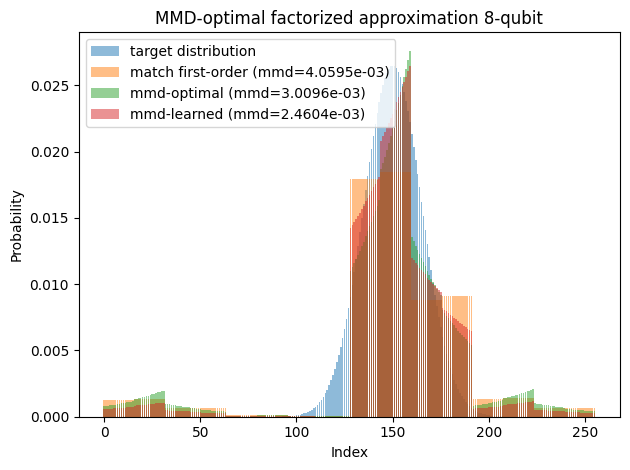


Top MMD contributions:
  k=00000000  hw=0  w*ĉ²=0.120564  ĉ=1.0000
  k=10000000  hw=1  w*ĉ²=0.027395  ĉ=-0.8664
  k=01000000  hw=1  w*ĉ²=0.027019  ĉ=0.8604
  k=11000000  hw=2  w*ĉ²=0.010916  ĉ=-0.9940
  k=00100000  hw=1  w*ĉ²=0.004235  ĉ=0.3407
  k=10100000  hw=2  w*ĉ²=0.002479  ĉ=-0.4737
  k=01100000  hw=2  w*ĉ²=0.002417  ĉ=0.4677
  k=00110000  hw=2  w*ĉ²=0.000731  ĉ=-0.2573
  k=01110000  hw=3  w*ĉ²=0.000472  ĉ=-0.3758
  k=10110000  hw=3  w*ĉ²=0.000458  ĉ=0.3701


In [35]:
n = 8
p = discretized_normal_probability((-10, 7), 2**n)

sigma = 0.1 * n
q1 = np.asarray(match_first_order(p))
q2 = match_mmd_optimal(p, sigma=sigma, hw_min=1, hw_max=4)
q3 = match_mmd_learn(p, sigma=sigma, hw_min=1, hw_max=4)

mmd_q1 = mmd_squared(p, q1, sigma)
mmd_q2 = mmd_squared(p, q2, sigma)
mmd_q3 = mmd_squared(p, q3, sigma)

print(f"MMD²(p, first-order) = {mmd_q1:.6f}")
print(f"MMD²(p, mmd-optimal) = {mmd_q2:.6f}")
print(f"MMD²(p, mmd-learned) = {mmd_q3:.6f}")

plot_distributions(
    [p, q1, q2, q3],
    labels=["target distribution", f"match first-order (mmd={mmd_q1:.4e})", f"mmd-optimal (mmd={mmd_q2:.4e})", f"mmd-learned (mmd={mmd_q3:.4e})"],
    title=f"MMD-optimal factorized approximation {n}-qubit",
)

contributions = sorted_mmd_contributions(p, sigma=sigma, hw_min=0, hw_max=3)
print("\nTop MMD contributions:")
for k, contrib, c in contributions[:10]:
    print(f"  k={k:0{n}b}  hw={hamming_weight(k)}  w*ĉ²={contrib:.6f}  ĉ={c:.4f}")